# Week 4 - Day 5
## Scikit-learn Pipeline & Tuned End-to-End Mini-Project

**Dataset:** Iris.csv

**Objective:**  
Build a professional, reproducible, and leakage-free machine learning pipeline
using Feature Engineering, ColumnTransformer, GridSearchCV, and Stratified
5-Fold Cross-Validation.

# Week 4 - Day 5
## Scikit-learn Pipeline & Tuned End-to-End Mini-Project

**Dataset:** Iris.csv

**Objective:**  
Build a professional, reproducible, and leakage-free machine learning pipeline
using Feature Engineering, ColumnTransformer, GridSearchCV, and Stratified
5-Fold Cross-Validation.

## 1. Import Libraries

In this section, we import all libraries required for data handling,
preprocessing, model building, hyperparameter tuning, and evaluation.

The main Scikit-learn components used today are:
- Pipeline
- ColumnTransformer
- StandardScaler
- GridSearchCV
- StratifiedKFold
- LogisticRegression

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.base import BaseEstimator, TransformerMixin

import matplotlib.pyplot as plt

## 2. Load the Iris Dataset

We load the Iris dataset from `Iris.csv`.

Before building any model, we first inspect the structure of the dataset,
including its dimensions, columns, data types, and missing values.

This prevents us from making assumptions about the data before preprocessing.

In [2]:
df = pd.read_csv("Iris.csv")

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (150, 6)

Columns:
['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

Data Types:
Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object

Missing Values:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


## 3. Target Distribution

The target variable is `Species`.

The Iris dataset contains three flower species. We inspect the number of
samples belonging to each class to understand the class distribution before
training the model.

This is especially important for classification because class imbalance can
affect model evaluation and cross-validation.

In [5]:
df["Species"].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [6]:
df["Species"].value_counts(normalize=True)

Species
Iris-setosa        0.333333
Iris-versicolor    0.333333
Iris-virginica     0.333333
Name: proportion, dtype: float64

## 4. Visualizing Class Distribution

The following bar chart shows how many samples belong to each Iris species.

We use this visualization to quickly check whether the target classes are
balanced.

A balanced distribution is useful for classification because the model is not
heavily biased toward one class.

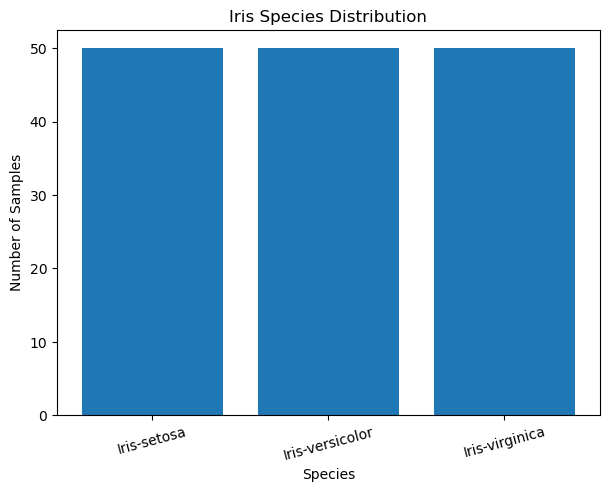

In [7]:
class_counts = df["Species"].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(class_counts.index, class_counts.values)

plt.title("Iris Species Distribution")
plt.xlabel("Species")
plt.ylabel("Number of Samples")

plt.xticks(rotation=15)
plt.show()

## 5. Define Features and Target

`Species` is our target variable because it is the value we want the model
to predict.

`Id` is removed because it is only an identifier and does not represent a
meaningful characteristic of the flower.

The remaining four measurements will be used as the original predictive
features.

In [8]:
X = df.drop(columns=["Species", "Id"])
y = df["Species"]

In [9]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget classes:")
print(y.unique())

X shape: (150, 4)
y shape: (150,)

Features:
['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

Target classes:
['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


## 6. Train/Test Split

We split the dataset into training and testing sets.

The training set will be used for:
- Feature engineering
- Preprocessing
- Cross-validation
- Hyperparameter tuning
- Model training

The test set will remain untouched during model selection.

We use `stratify=y` to preserve the class distribution in both sets.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [11]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nTraining distribution:")
print(y_train.value_counts())

print("\nTest distribution:")
print(y_test.value_counts())

X_train: (120, 4)
X_test: (30, 4)

Training distribution:
Species
Iris-setosa        40
Iris-virginica     40
Iris-versicolor    40
Name: count, dtype: int64

Test distribution:
Species
Iris-setosa        10
Iris-virginica     10
Iris-versicolor    10
Name: count, dtype: int64


## 7. Build a Baseline Model

Before tuning the final pipeline, we create a simple baseline model.

The baseline gives us a reference point that allows us to determine whether
feature engineering and hyperparameter tuning actually improve performance.

The baseline uses:
- StandardScaler
- Logistic Regression

No GridSearchCV or engineered features are used at this stage.

In [12]:
baseline_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

In [13]:
baseline_pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [14]:
y_pred_baseline = baseline_pipeline.predict(X_test)

## 8. Evaluate the Baseline

We evaluate the baseline using:
- Accuracy
- Macro F1-score

Macro F1 is appropriate here because Iris is a multiclass classification
problem with three target classes.

This baseline will later be compared with the tuned pipeline.

In [15]:
baseline_accuracy = accuracy_score(
    y_test,
    y_pred_baseline
)

baseline_f1 = f1_score(
    y_test,
    y_pred_baseline,
    average="macro"
)

print("Baseline Accuracy:", baseline_accuracy)
print("Baseline F1 Macro:", baseline_f1)

Baseline Accuracy: 0.9333333333333333
Baseline F1 Macro: 0.9333333333333332


In [16]:
print(
    classification_report(
        y_test,
        y_pred_baseline
    )
)

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



## 9. Feature Engineering

Feature engineering creates additional features from the original measurements.

For the Iris dataset, we create geometric relationships between the flower
measurements:

- `SepalArea` = SepalLength × SepalWidth
- `PetalArea` = PetalLength × PetalWidth
- `PetalRatio` = PetalLength / PetalWidth
- `SepalRatio` = SepalLength / SepalWidth

These features may provide the model with additional information about the
shape and proportions of the flowers.

The feature engineering step will later be placed inside the Pipeline so that
it is performed correctly during cross-validation.

In [17]:
class IrisFeatureEngineer(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        X["SepalArea"] = (
            X["SepalLengthCm"] *
            X["SepalWidthCm"]
        )

        X["PetalArea"] = (
            X["PetalLengthCm"] *
            X["PetalWidthCm"]
        )

        X["PetalRatio"] = (
            X["PetalLengthCm"] /
            X["PetalWidthCm"].replace(0, np.nan)
        )

        X["SepalRatio"] = (
            X["SepalLengthCm"] /
            X["SepalWidthCm"].replace(0, np.nan)
        )

        X = X.replace(
            [np.inf, -np.inf],
            np.nan
        )

        X = X.fillna(0)

        return X

## 10. Check the Engineered Features

Before placing the transformer inside the final pipeline, we verify that it
creates the expected additional features.

This is a simple sanity check to make sure the transformation works correctly.

In [18]:
feature_engineer = IrisFeatureEngineer()

X_train_engineered = feature_engineer.fit_transform(
    X_train
)

X_train_engineered.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,SepalArea,PetalArea,PetalRatio,SepalRatio
8,4.4,2.9,1.4,0.2,12.76,0.28,7.000000,1.517241
106,4.9,2.5,4.5,1.7,12.25,7.65,2.647059,1.960000
76,6.8,2.8,4.8,1.4,19.04,6.72,3.428571,2.428571
9,4.9,3.1,1.5,0.1,15.19,0.15,15.000000,1.580645
89,5.5,2.5,4.0,1.3,13.75,5.20,3.076923,2.200000


In [19]:
print(
    X_train_engineered.columns.tolist()
)

['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'SepalArea', 'PetalArea', 'PetalRatio', 'SepalRatio']


## 11. Define Numeric Features

After feature engineering, all predictive variables are numeric.

Therefore, we will apply numerical preprocessing to all engineered features.

The target `Species` is not included because it is the value we are trying
to predict, not an input feature.

In [20]:
numeric_features = [
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm",
    "SepalArea",
    "PetalArea",
    "PetalRatio",
    "SepalRatio"
]

## 12. Build the ColumnTransformer

We use `ColumnTransformer` to define how different groups of features should
be preprocessed.

In this dataset, all predictive variables are numerical, so we apply
`StandardScaler` to the numerical features.

Although there are no categorical input features in Iris, using
ColumnTransformer keeps the preprocessing structure clean and extensible.

In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        )
    ],
    remainder="drop"
)

## 13. Build the End-to-End Pipeline

We now combine the entire workflow into one Pipeline:

1. Feature Engineering
2. Preprocessing
3. Logistic Regression

Keeping these steps together prevents preprocessing from accidentally being
performed using information from validation or test data.

This is the main concept of Day 5: instead of manually performing each step,
we create one reproducible machine learning workflow.

In [22]:
pipeline = Pipeline([
    (
        "feature_engineering",
        IrisFeatureEngineer()
    ),
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        LogisticRegression(
            max_iter=2000
        )
    )
])

## 14. Test the Pipeline Before Tuning

Before running GridSearchCV, we verify that the complete pipeline can be
trained and used for prediction successfully.

This is a technical sanity check, not the final evaluation.

In [23]:
pipeline.fit(
    X_train,
    y_train
)

,steps,"[('feature_engineering', ...), ('preprocessor', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [24]:
y_pred = pipeline.predict(X_test)

print(
    "Pipeline Accuracy:",
    accuracy_score(y_test, y_pred)
)

Pipeline Accuracy: 0.9666666666666667


## 15. Stratified 5-Fold Cross-Validation

Because this is a multiclass classification problem, we use
`StratifiedKFold`.

The dataset is divided into five folds while preserving the class distribution
as much as possible in every fold.

Each fold is used once for validation while the remaining four folds are used
for training.

This gives GridSearchCV a more reliable estimate than relying on one validation
split.

In [25]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## 16. Define the Hyperparameter Grid

We will tune the Logistic Regression `C` parameter.

`C` controls the strength of regularization:

- Smaller values apply stronger regularization.
- Larger values apply weaker regularization.

Because the model is inside a Pipeline under the name `model`, the parameter
must be written using the Pipeline syntax:

`model__C`

In [26]:
param_grid = {
    "model__C": [
        0.01,
        0.1,
        1,
        10,
        100
    ],
    "model__solver": [
        "lbfgs"
    ]
}

## 17. Build GridSearchCV

GridSearchCV will test every hyperparameter combination using the
Stratified 5-Fold Cross-Validation strategy.

We use `f1_macro` as the optimization metric because the Iris problem contains
three classes.

The test set is not passed to GridSearchCV.

In [27]:
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    return_train_score=True
)

## 18. Train GridSearchCV

GridSearchCV now trains multiple versions of the complete pipeline.

For every configuration:

1. Feature engineering is performed.
2. Scaling is fitted on the training portion of the fold.
3. The model is trained.
4. The validation portion is evaluated.
5. The process is repeated across all five folds.

This structure prevents preprocessing leakage during cross-validation.

In [28]:
grid_search.fit(
    X_train,
    y_train
)

,estimator,Pipeline(step..._iter=2000))])
,param_grid,"{'model__C': [0.01, 0.1, ...], 'model__solver': ['lbfgs']}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('num', ...)]"


## 19. Best Hyperparameters

After testing all configurations, GridSearchCV selects the configuration
with the highest mean cross-validated F1 Macro score.

We now inspect the winning configuration.

In [29]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'model__C': 10, 'model__solver': 'lbfgs'}


In [30]:
print("Best CV F1 Macro:")
print(grid_search.best_score_)

Best CV F1 Macro:
0.9663367569249923


In [31]:
best_pipeline = grid_search.best_estimator_

## 20. GridSearchCV Results

We convert the GridSearchCV results into a DataFrame.

This allows us to compare the tested hyperparameter configurations and inspect
their mean validation score and standard deviation.

The standard deviation indicates how much the performance varied between folds.

In [32]:
results = pd.DataFrame(
    grid_search.cv_results_
)

results[
    [
        "param_model__C",
        "mean_test_score",
        "std_test_score",
        "mean_train_score"
    ]
].sort_values(
    by="mean_test_score",
    ascending=False
)

,param_model__C,mean_test_score,std_test_score,mean_train_score
3,10.00,0.966337,0.031623,0.981247
4,100.00,0.966337,0.031623,0.985416
1,0.10,0.950359,0.039967,0.958305
2,1.00,0.950040,0.031066,0.972909
0,0.01,0.899888,0.056055,0.912251


## 21. Visualizing Hyperparameter Performance

The following chart shows how the mean cross-validated F1 Macro score changes
for different values of the Logistic Regression `C` parameter.

The purpose of this chart is to understand the effect of the hyperparameter
rather than simply accepting the best value returned by GridSearchCV.

The highest point represents the best mean cross-validation performance among
the tested values.

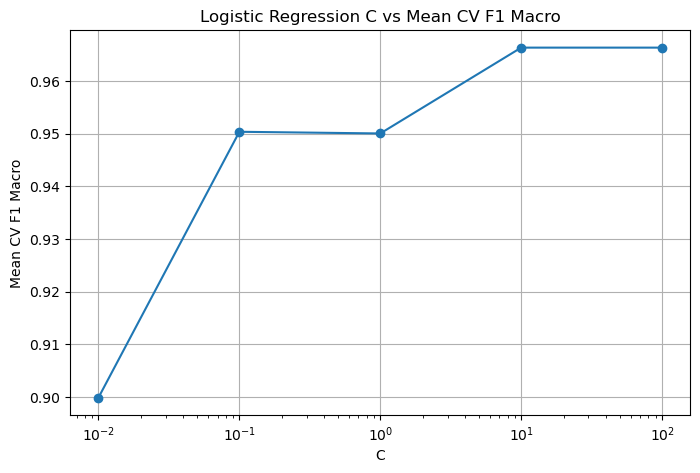

In [33]:
grid_results = results.sort_values(
    by="param_model__C"
)

plt.figure(figsize=(8, 5))

plt.plot(
    grid_results["param_model__C"].astype(float),
    grid_results["mean_test_score"],
    marker="o"
)

plt.xscale("log")

plt.title(
    "Logistic Regression C vs Mean CV F1 Macro"
)

plt.xlabel("C")
plt.ylabel("Mean CV F1 Macro")

plt.grid(True)
plt.show()

## 21. Visualizing Hyperparameter Performance

The following chart shows how the mean cross-validated F1 Macro score changes
for different values of the Logistic Regression `C` parameter.

The purpose of this chart is to understand the effect of the hyperparameter
rather than simply accepting the best value returned by GridSearchCV.

The highest point represents the best mean cross-validation performance among
the tested values.

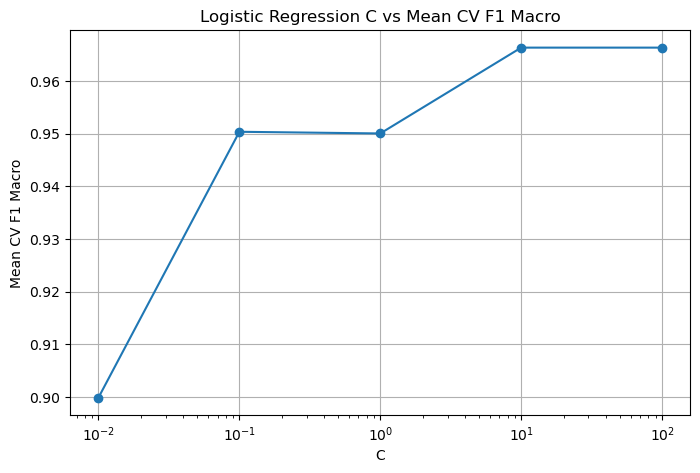

In [34]:
grid_results = results.sort_values(
    by="param_model__C"
)

plt.figure(figsize=(8, 5))

plt.plot(
    grid_results["param_model__C"].astype(float),
    grid_results["mean_test_score"],
    marker="o"
)

plt.xscale("log")

plt.title(
    "Logistic Regression C vs Mean CV F1 Macro"
)

plt.xlabel("C")
plt.ylabel("Mean CV F1 Macro")

plt.grid(True)
plt.show()

## 22. Inspect the Best Pipeline

We inspect the final pipeline selected by GridSearchCV.

The pipeline contains all preprocessing and modeling steps required to make
predictions from the original Iris features.

This makes the final model reproducible and easy to save or deploy later.

In [35]:
print(best_pipeline)

Pipeline(steps=[('feature_engineering', IrisFeatureEngineer()),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SepalLengthCm',
                                                   'SepalWidthCm',
                                                   'PetalLengthCm',
                                                   'PetalWidthCm', 'SepalArea',
                                                   'PetalArea', 'PetalRatio',
                                                   'SepalRatio'])])),
                ('model', LogisticRegression(C=10, max_iter=2000))])


## 23. Final Evaluation on the Held-Out Test Set

All model and hyperparameter decisions are now complete.

Only at this stage do we evaluate the selected pipeline on the test set.

The test set was not used during:
- Feature/model selection
- GridSearchCV
- Hyperparameter tuning

Therefore, this score provides our final estimate of performance on unseen data.

In [36]:
y_pred_final = best_pipeline.predict(
    X_test
)

In [37]:
final_accuracy = accuracy_score(
    y_test,
    y_pred_final
)

final_f1 = f1_score(
    y_test,
    y_pred_final,
    average="macro"
)

print("Final Accuracy:", final_accuracy)
print("Final F1 Macro:", final_f1)

Final Accuracy: 1.0
Final F1 Macro: 1.0


## 24. Final Classification Report

The classification report provides precision, recall, and F1-score for each
Iris species.

This allows us to see whether the model performs equally well across the
three classes instead of relying only on overall accuracy.

In [38]:
print(
    classification_report(
        y_test,
        y_pred_final
    )
)

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



## 25. Final Confusion Matrix

The confusion matrix shows how many samples from each actual class were
correctly or incorrectly classified.

Rows represent the actual classes, while columns represent the predicted
classes.

A strong classifier should have most values concentrated along the diagonal.

In [39]:
cm = confusion_matrix(
    y_test,
    y_pred_final
)

print(cm)

[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


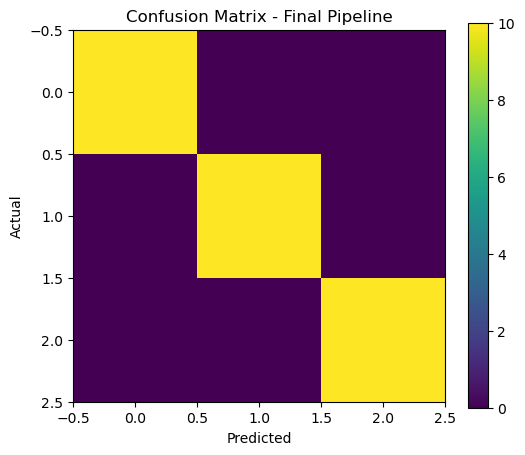

In [40]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title(
    "Confusion Matrix - Final Pipeline"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.colorbar()

plt.show()

## 26. Baseline vs Tuned Pipeline

The final step is to compare the tuned pipeline with the baseline model.

This comparison tells us whether the additional work performed during Day 5,
including feature engineering and hyperparameter tuning, actually improved
the model's performance.

In [41]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Tuned Pipeline"
    ],
    "Accuracy": [
        baseline_accuracy,
        final_accuracy
    ],
    "F1 Macro": [
        baseline_f1,
        final_f1
    ]
})

comparison

,Model,Accuracy,F1 Macro
0,Baseline,0.933333,0.933333
1,Tuned Pipeline,1.000000,1.000000


## 27. Visualizing Model Comparison

The following chart compares the baseline and tuned pipeline using Accuracy.

The purpose is to make the performance difference easier to interpret
visually.

If the tuned pipeline has a higher bar, the tuning and feature engineering
improved the selected metric on the held-out test set.

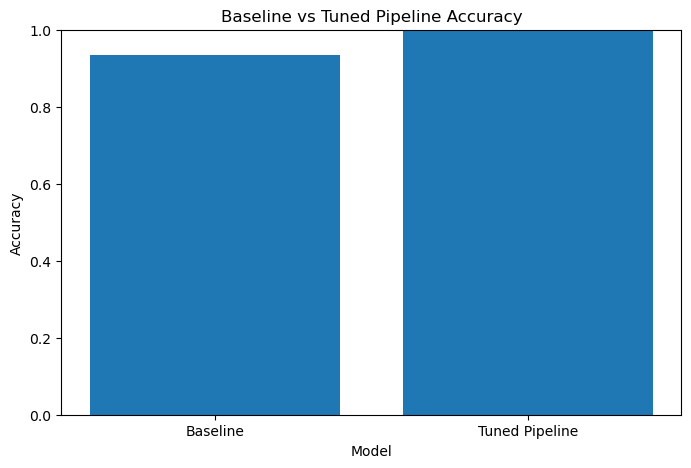

In [42]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.title(
    "Baseline vs Tuned Pipeline Accuracy"
)

plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.ylim(0, 1)

plt.show()

## 28. Measure the Improvement

We calculate the difference between the tuned pipeline and the baseline.

This allows us to quantify the effect of the improvements rather than relying
only on visual comparison.

In [43]:
accuracy_improvement = (
    final_accuracy -
    baseline_accuracy
)

f1_improvement = (
    final_f1 -
    baseline_f1
)

print(
    "Accuracy improvement:",
    accuracy_improvement
)

print(
    "F1 Macro improvement:",
    f1_improvement
)

Accuracy improvement: 0.06666666666666665
F1 Macro improvement: 0.06666666666666676


## 29. Leakage Prevention

The final workflow was designed to prevent data leakage.

Feature engineering and scaling are inside the Pipeline.

GridSearchCV receives only the training data.

During each cross-validation fold, preprocessing is fitted only on that fold's
training portion.

The held-out test set is used only for the final evaluation after all
hyperparameter decisions are complete.

Therefore, information from the test set does not influence model selection.

## 30. Feature Engineering Summary

Four engineered features were created:

1. `SepalArea`
   - SepalLength × SepalWidth
   - Represents an approximate sepal surface area.

2. `PetalArea`
   - PetalLength × PetalWidth
   - Represents an approximate petal area.

3. `PetalRatio`
   - PetalLength / PetalWidth
   - Represents the proportion between petal length and width.

4. `SepalRatio`
   - SepalLength / SepalWidth
   - Represents the proportion between sepal length and width.

These features were included inside the Pipeline so that their transformation
is consistently applied during training, cross-validation, and prediction.

## 31. Hyperparameter Tuning Summary

GridSearchCV was used to tune Logistic Regression.

The searched hyperparameters were:

- `C`: [0.01, 0.1, 1, 10, 100]
- `solver`: ["lbfgs"]

A Stratified 5-Fold Cross-Validation strategy was used.

The optimization metric was Macro F1 because the problem is a multiclass
classification task.

The best configuration was selected using the highest mean cross-validated
score.